In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# 1. Load the data
df = pd.read_csv('../data/raw/aromatase_raw_verified.csv')

In [5]:
df.head()

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,confidence_score
0,CHEMBL341591,CC12CCC(O)CC1=CCC1C2CCC2(C)C(CC3CN3)CCC12,IC50,7100.0,nM,9
1,CHEMBL2111947,C[C@]12CC[C@H]3[C@@H](CC=C4C[C@@H](O)CC[C@@]43...,IC50,50000.0,nM,9
2,CHEMBL431859,CCn1c(C(c2ccc(F)cc2)n2ccnc2)c(C)c2cc(Br)ccc21,IC50,238.0,nM,9
3,CHEMBL113637,CCn1cc(C(c2ccc(F)cc2)n2ccnc2)c2ccccc21,IC50,57.0,nM,9
4,CHEMBL112021,Clc1ccccc1Cn1cc(Cn2ccnc2)c2ccccc21,IC50,54.0,nM,9


In [6]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 3496 rows, 6 columns


In [7]:
# Null Values (Empty Cells)
print("\nNull Values per column:")
print(df.isnull().sum())


Null Values per column:
molecule_chembl_id    0
canonical_smiles      0
standard_type         0
standard_value        0
standard_units        0
confidence_score      0
dtype: int64


In [8]:
print("\n=== 2. CHEMICAL DUPLICATE CHECKS ===")
# In chemistry databases, multiple labs often test the exact same molecule.
unique_smiles = df['canonical_smiles'].nunique()
duplicates = len(df) - unique_smiles
print(f"Total Unique Molecules: {unique_smiles}")
print(f"Duplicate SMILES entries: {duplicates}")


=== 2. CHEMICAL DUPLICATE CHECKS ===
Total Unique Molecules: 2682
Duplicate SMILES entries: 814


In [9]:
print("\n=== 3. SKEWNESS & DISTRIBUTION CHECKS ===")
# Check skewness of the raw IC50 values
ic50_skew = df['standard_value'].skew()
print(f"Raw IC50 Skewness: {ic50_skew:.2f}")


=== 3. SKEWNESS & DISTRIBUTION CHECKS ===
Raw IC50 Skewness: 3.80


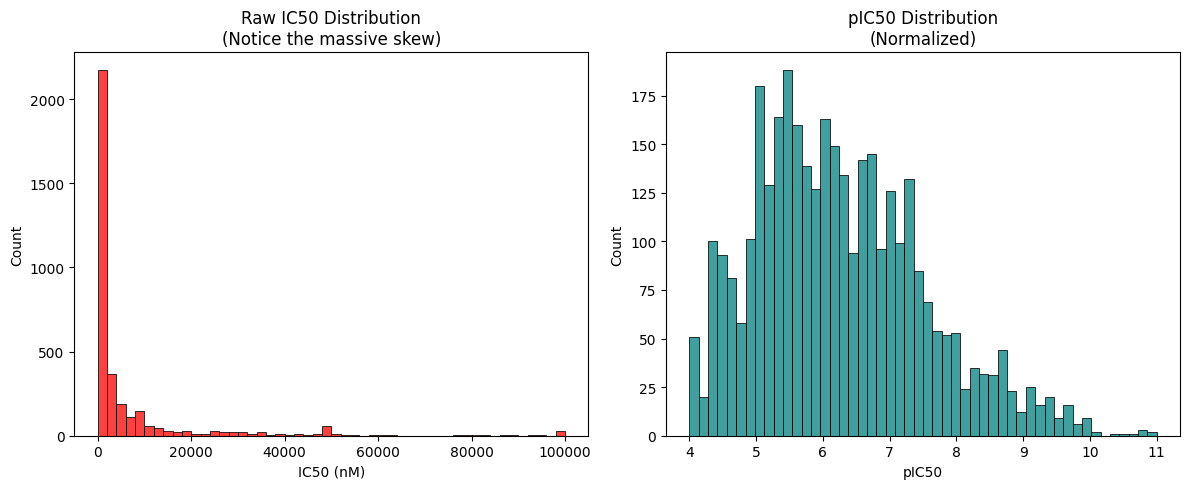

In [10]:
# Visualize the skewness vs log-transformed data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Raw IC50 (Highly Skewed)
sns.histplot(df['standard_value'], bins=50, ax=ax1, color='red')
ax1.set_title("Raw IC50 Distribution\n(Notice the massive skew)")
ax1.set_xlabel("IC50 (nM)")

# Plot B: pIC50 (Log Transformed)
# pIC50 = -log10(IC50 in Molar). It normalizes the skew.
df['pIC50'] = 9 - np.log10(df['standard_value'] + 1e-10)
sns.histplot(df['pIC50'], bins=50, ax=ax2, color='teal')
ax2.set_title("pIC50 Distribution\n(Normalized)")
ax2.set_xlabel("pIC50")

plt.tight_layout()
plt.show()

In [14]:
# 1. Basic Stats
total_records = len(df)
unique_smiles = df['canonical_smiles'].nunique()

In [11]:
unique_smiles = df['canonical_smiles'].nunique()

# 2. Handle duplicates (average the standard_value for identical SMILES)
df_grouped = df.groupby('canonical_smiles', as_index=False).agg({
    'molecule_chembl_id': 'first',
    'standard_value': 'mean',
    'standard_units': 'first',
    'confidence_score': 'first'
})
unique_records = len(df_grouped)

In [12]:
# 3. Transform IC50 to pIC50 for better visualization
# pIC50 = -log10(IC50 in Molar) = 9 - log10(IC50 in nM)
# Adding a small epsilon to avoid log(0) just in case
df_grouped['pIC50'] = 9 - np.log10(df_grouped['standard_value'] + 1e-10)

# 4. Classify based on project scoping thresholds
def classify_activity(ic50):
    if ic50 < 1000:
        return 'Active (< 1 \u00b5M)'
    elif ic50 > 10000:
        return 'Inactive (> 10 \u00b5M)'
    else:
        return 'Intermediate'

df_grouped['Activity_Class'] = df_grouped['standard_value'].apply(classify_activity)
class_counts = df_grouped['Activity_Class'].value_counts()

C:\Users\HOME\AppData\Local\Temp\ipykernel_33204\3598891985.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_grouped, x='Activity_Class', order=['Active (< 1 \u00b5M)', 'Intermediate', 'Inactive (> 10 \u00b5M)'], palette=['#2ecc71', '#f1c40f', '#e74c3c'], ax=ax2)


Total Raw Records: 3496
Unique Molecules (SMILES): 2682

Activity Class Distribution:
Activity_Class
Active (< 1 µM)       1333
Intermediate           915
Inactive (> 10 µM)     434


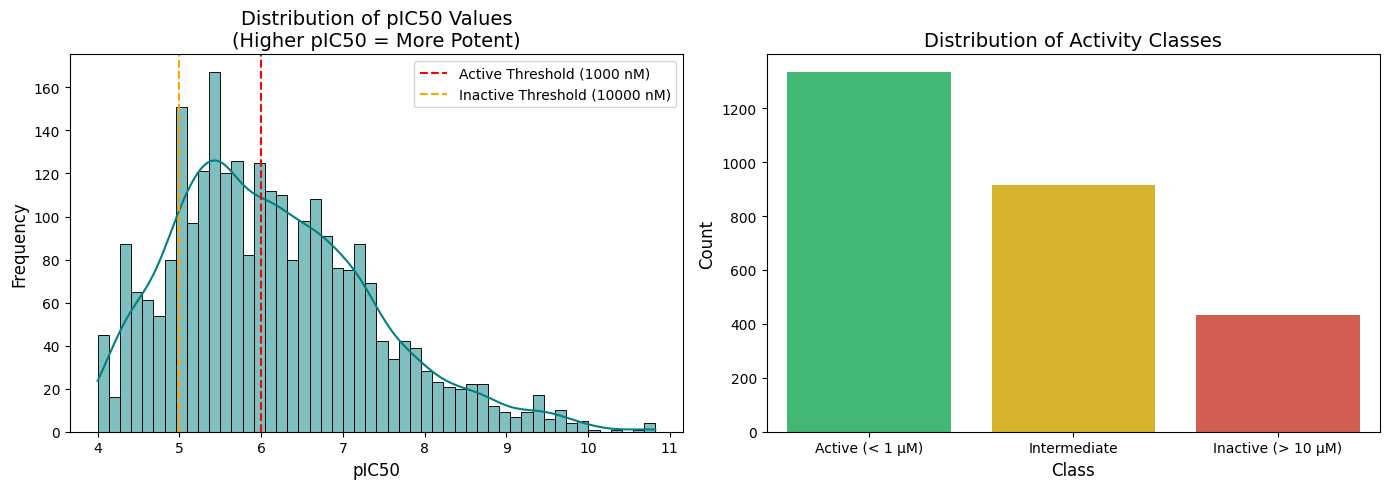

In [15]:
# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: pIC50 Distribution
sns.histplot(df_grouped['pIC50'], bins=50, kde=True, ax=ax1, color='teal')
ax1.set_title('Distribution of pIC50 Values\n(Higher pIC50 = More Potent)', fontsize=14)
ax1.set_xlabel('pIC50', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
# Draw threshold lines
ax1.axvline(x=6, color='red', linestyle='--', label='Active Threshold (1000 nM)')
ax1.axvline(x=5, color='orange', linestyle='--', label='Inactive Threshold (10000 nM)')
ax1.legend()

# Plot B: Activity Classes
sns.countplot(data=df_grouped, x='Activity_Class', order=['Active (< 1 \u00b5M)', 'Intermediate', 'Inactive (> 10 \u00b5M)'], palette=['#2ecc71', '#f1c40f', '#e74c3c'], ax=ax2)
ax2.set_title('Distribution of Activity Classes', fontsize=14)
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=300)

print(f"Total Raw Records: {total_records}")
print(f"Unique Molecules (SMILES): {unique_records}")
print("\nActivity Class Distribution:")
print(class_counts.to_string())

In [16]:
df_processed = pd.read_csv('../data/processed/aromatase_cleaned_binarized.csv')

In [17]:
df_processed.head()

,molecule_chembl_id,canonical_smiles,standard_value,pIC50,active
0,CHEMBL1939521,Brc1ccc(-c2nsc(-c3ccc(Br)cc3)n2)cc1,50000.000,4.301030,0
1,CHEMBL436369,Brc1ccc(C(c2ccc(Br)cc2)n2ccnc2)cc1,8.892,8.051001,1
2,CHEMBL350338,Brc1ccc(C2CCCc3cncn32)cc1,7.603,8.119015,1
3,CHEMBL1203766,Brc1ccc(C2CCCc3cncn32)cc1.Cl,7.600,8.119186,1
4,CHEMBL211207,Brc1ccc(Cn2ccnc2)cc1,338.840,6.470005,1
